# Imports and setups

In [1]:
import tensorflow as tf
from tensorflow.python.platform import self_check

gpus = tf.config.list_physical_devices('GPU')
print("GPUs:", gpus)

if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print("Memory growth enabled")
    except Exception as e:
        print("Could not set memory growth:", e)

GPUs: []


In [2]:
import tensorflow as tf
from tensorflow.keras.layers import Layer, Conv2D, Dense, MaxPooling2D, Input, Flatten
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir("D:/Facial Recognition/")
import cv2 
import uuid
tf.config.list_physical_devices('GPU')

[]

# Creating folder structure

In [3]:
POSITIVES = os.path.join("data", "positive")
NEGATIVES = os.path.join("data", "negative")
ANCHORS = os.path.join("data", "anchors")
dirs = [POSITIVES, NEGATIVES, ANCHORS]
for dir in dirs :
    os.makedirs(dir, exist_ok = True)
print(os.path.abspath("data"))

D:\Facial Recognition\data


In [4]:
for directory in os.listdir("lfw"):
    for filename in os.listdir(os.path.join("lfw", directory)):
        EX_PATH = os.path.join("lfw", directory, filename)
        NEW_PATH = os.path.join(NEGATIVES, filename)
        os.replace(EX_PATH, NEW_PATH)

In [4]:
for filename in os.listdir(NEGATIVES):
    print(os.path.join(NEGATIVES, filename))

data\negative\Aaron_Eckhart_0001.jpg
data\negative\Aaron_Guiel_0001.jpg
data\negative\Aaron_Patterson_0001.jpg
data\negative\Aaron_Peirsol_0001.jpg
data\negative\Aaron_Peirsol_0002.jpg
data\negative\Aaron_Peirsol_0003.jpg
data\negative\Aaron_Peirsol_0004.jpg
data\negative\Aaron_Pena_0001.jpg
data\negative\Aaron_Sorkin_0001.jpg
data\negative\Aaron_Sorkin_0002.jpg
data\negative\Aaron_Tippin_0001.jpg
data\negative\Abbas_Kiarostami_0001.jpg
data\negative\Abba_Eban_0001.jpg
data\negative\Abdel_Aziz_Al-Hakim_0001.jpg
data\negative\Abdel_Madi_Shabneh_0001.jpg
data\negative\Abdel_Nasser_Assidi_0001.jpg
data\negative\Abdel_Nasser_Assidi_0002.jpg
data\negative\Abdoulaye_Wade_0001.jpg
data\negative\Abdoulaye_Wade_0002.jpg
data\negative\Abdoulaye_Wade_0003.jpg
data\negative\Abdoulaye_Wade_0004.jpg
data\negative\Abdulaziz_Kamilov_0001.jpg
data\negative\Abdullah_0001.jpg
data\negative\Abdullah_0002.jpg
data\negative\Abdullah_0003.jpg
data\negative\Abdullah_0004.jpg
data\negative\Abdullah_Ahmad_Badaw

# Accessing the WebCam using OpenCV

In [6]:
# verifying if the camera be worken
cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FOURCC, cv2.VideoWriter_fourcc(*"MJPG"))
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

print("opened:", cap.isOpened())
ret, frame = cap.read()
print("ret:", ret)

opened: True
ret: True


In [5]:
cap = cv2.VideoCapture(0)
while cap.isOpened() :
    ret, frame = cap.read()
    if not ret :
        break

    frame = frame[120 : 120 + 250, 200 : 200 + 250, :]
    cv2.imshow("Image Collection", frame)
    # collecting the anchors
    if (cv2.waitKey(1) & 0xFF == ord('a')) :
        imgname = os.path.join(ANCHORS, "{}.jpg".format(uuid.uuid1()))
        cv2.imwrite(imgname, frame)
    # collecting the positives
    if (cv2.waitKey(1) & 0xFF == ord('p')) :
        imgname = os.path.join(POSITIVES, "{}.jpg".format(uuid.uuid1()))
        cv2.imwrite(imgname, frame)
    # collecting the negatives
    if (cv2.waitKey(1) & 0xFF == ord('n')) :
        imgname = os.path.join(NEGATIVES, "{}.jpg".format(uuid.uuid1()))
        cv2.imwrite(imgname, frame)

    if (cv2.waitKey(1) & 0xFF == ord('q')) :
        break
cap.release()
cv2.destroyAllWindows()

In [ ]:
import os
import cv2
import numpy as np
from IPython.display import display
from PIL import Image

PHONE_STREAM_URL = os.getenv("PHONE_STREAM_URL", "http://192.168.0.108:8080/video")
print("Using phone stream URL:", PHONE_STREAM_URL)

cap = cv2.VideoCapture(PHONE_STREAM_URL)

if not cap.isOpened():
    raise RuntimeError(
        "Could not open the phone stream.\n"
        "Check that IP Webcam is running on your phone and that the URL is correct."
    )

cap.set(cv2.CAP_PROP_FRAME_WIDTH, 320)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 240)

print("Phone stream opened successfully")
print("Press q in the notebook cell output to stop")

for _ in range(30):
    ret, frame = cap.read()
    if not ret:
        print("Failed to read a frame from the phone stream")
        break

    frame = cv2.resize(frame, (320, 240))
    frame = frame[120 : 120 + 250, 200 : 200 + 250, :]
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    img = Image.fromarray(frame_rgb)
    display(img)

cap.release()

Using phone stream URL: http://192.168.0.108:8080/video


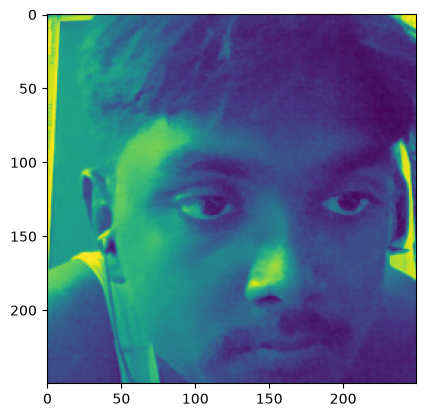

In [20]:
plt.imshow(frame[:, :, 1])

In [37]:
anchor = tf.data.Dataset.list_files(ANCHORS + "\\*.jpg").take(300)
positive = tf.data.Dataset.list_files(POSITIVES + "\\*.jpg").take(300)
negative = tf.data.Dataset.list_files(NEGATIVES + "\\*.jpg").take(300)

In [16]:
ANCHORS

'data\\anchors'

In [145]:
def preprocess (file_path) :
    """
    Params : file_path
    Preprocesses the images for the neural network by resizing to (100, 100) and scaling b/w [0, 1] by dividing by 255.0
    """
    byte_img = tf.io.read_file(file_path)
    img = tf.io.decode_jpeg(byte_img)
    img = tf.image.resize(img, (100, 100))
    # scaling b/w 0 and 1 to make sure numbers dont go all over the place
    img /= 255
    return img


Text(0.5, 1.0, 'BUGGU (scaled down to [100 : 100])')

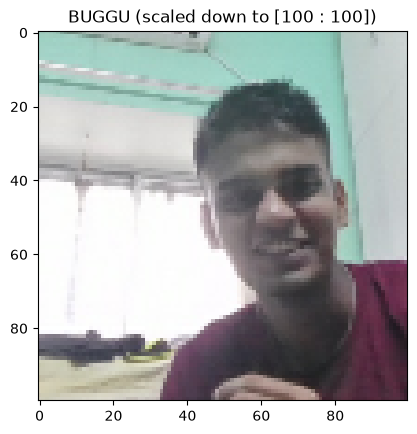

In [146]:
plt.imshow(preprocess("data//anchors//8638ff34-8f22-11f1-8029-00155dcd2f0b.jpg"))
plt.title("BUGGU (scaled down to [100 : 100])")

In [147]:
preprocess("data//anchors//51a6b4a8-8e5e-11f1-ad31-be86ceb3559f.jpg").numpy()[:, :, 1].min()

np.float32(0.0700392)

# Creating Labelled Dataset

In [148]:
positive_dataset = tf.data.Dataset.zip((
    anchor,
    positive,
    tf.data.Dataset.from_tensor_slices(tf.ones([len(anchor)], dtype = tf.float32))
))
negative_dataset = tf.data.Dataset.zip((
    anchor,
    negative,
    tf.data.Dataset.from_tensor_slices(tf.zeros([len(anchor)], dtype = tf.float32))
))
data = positive_dataset.concatenate(negative_dataset)

In [149]:
for element in data : print(data.as_numpy_iterator().next())

(b'data\\anchors\\88327136-8f22-11f1-b974-00155dcd2f0b.jpg', b'data\\positive\\8638ff34-8f22-11f1-8029-00155dcd2f0b.jpg', np.float32(1.0))
(b'data\\anchors\\45f8889f-8e9a-11f1-b8a6-be86ceb3559f.jpg', b'data\\positive\\4a3e6fa9-8e9a-11f1-b83d-be86ceb3559f.jpg', np.float32(1.0))
(b'data\\anchors\\481cb018-8e9a-11f1-ab4a-be86ceb3559f.jpg', b'data\\positive\\8c642481-8f22-11f1-ade3-00155dcd2f0b.jpg', np.float32(1.0))
(b'data\\anchors\\484c31b0-8e9a-11f1-a56b-be86ceb3559f.jpg', b'data\\positive\\88e9a332-8f22-11f1-abc9-00155dcd2f0b.jpg', np.float32(1.0))
(b'data\\anchors\\510c1d73-8e9a-11f1-b7fb-be86ceb3559f.jpg', b'data\\positive\\8bbceca9-8f22-11f1-978f-00155dcd2f0b.jpg', np.float32(1.0))
(b'data\\anchors\\45f8889f-8e9a-11f1-b8a6-be86ceb3559f.jpg', b'data\\positive\\48c08c6e-8e5e-11f1-a5eb-be86ceb3559f.jpg', np.float32(1.0))
(b'data\\anchors\\88e9a332-8f22-11f1-abc9-00155dcd2f0b.jpg', b'data\\positive\\4bb83300-8e9a-11f1-95f1-be86ceb3559f.jpg', np.float32(1.0))
(b'data\\anchors\\48368956-

# Build Test and Train partition

In [150]:
samples = data.as_numpy_iterator()

In [151]:
example = samples.next()
example

(b'data\\anchors\\48368956-8e5e-11f1-9b10-be86ceb3559f.jpg',
 b'data\\positive\\45f8889f-8e9a-11f1-b8a6-be86ceb3559f.jpg',
 np.float32(1.0))

In [152]:
type(example[2])

numpy.float32

In [153]:
def preprocess_positive (input_img, validation_img, label) :
    """

    """
    return(preprocess(input_img), preprocess(validation_img), label)

Text(0.5, 1.0, 'Boro botla')

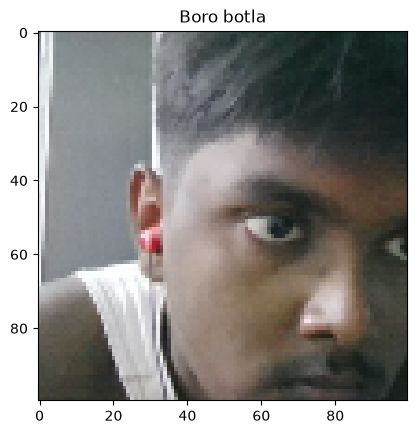

In [154]:
plt.imshow(preprocess_positive(*example)[1])
plt.title("Boro botla")

In [155]:
data = data.map(preprocess_positive)
data = data.cache()
data = data.shuffle(buffer_size = 1024)

In [110]:
data

<_ShuffleDataset element_spec=(TensorSpec(shape=(100, 100, None), dtype=tf.float32, name=None), TensorSpec(shape=(100, 100, None), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.float32, name=None))>

tuple